# Trader Behavior Insights: Performance vs Bitcoin Market Sentiment

**Objective:** Explore the relationship between trader performance (Hyperliquid historical trade data) and Bitcoin market sentiment (Fear & Greed Index), uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

**Datasets**
1. `csv_files/historical_trader_data.csv` — Hyperliquid trades: account, coin, execution price, size, side, timestamp, start position, direction, closed PnL, fees, etc.
2. `csv_files/fear_greed_index.csv` — daily Bitcoin Fear & Greed Index: date, value (0–100), classification (Extreme Fear / Fear / Neutral / Greed / Extreme Greed).

**Approach:** merge each trade to the sentiment of its calendar day, then compare performance (PnL, win rate, payoff ratio, efficiency), behavior (direction, sizing, volume), and risk across the five sentiment regimes. Statistical tests validate the headline differences. All charts are saved to `outputs/`.


In [1]:
# If running on Google Colab, uncomment to fetch the data:
# !git clone https://github.com/rhushi8/ds_rhushikesh.git
# %cd ds_rhushikesh

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

trades = pd.read_csv("csv_files/historical_trader_data.csv")
fg = pd.read_csv("csv_files/fear_greed_index.csv")
print(trades.shape, fg.shape)

(211224, 16) (2644, 4)


## 1. Data profiling & preparation

In [2]:
print("=== TRADER DATA ===")
print("rows:", len(trades), "| accounts:", trades["Account"].nunique(), "| coins:", trades["Coin"].nunique())
trades["dt"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["dt"].dt.normalize()
print("date range:", trades["dt"].min(), "->", trades["dt"].max())
print("nulls:", trades.isna().sum().sum(), "| duplicate rows:", trades.duplicated().sum())
print("total closed PnL: $", round(trades["Closed PnL"].sum(), 0))
trades.head(3)

=== TRADER DATA ===
rows: 211224 | accounts: 32 | coins: 246
date range: 2023-05-01 01:06:00 -> 2025-05-01 12:13:00


nulls: 0 | duplicate rows: 0
total closed PnL: $ 10296959.0


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,dt,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,"895,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,"443,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,02-12-2024 22:50,"1,002.52",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"660,000,000,000,000.00","1,730,000,000,000.00",2024-12-02 22:50:00,2024-12-02


In [3]:
print("=== FEAR/GREED INDEX ===")
fg["date"] = pd.to_datetime(fg["date"])
fg = fg.rename(columns={"value": "fg_value", "classification": "sentiment"})
print("rows:", len(fg), "| range:", fg["date"].min().date(), "->", fg["date"].max().date(),
      "| duplicate dates:", fg["date"].duplicated().sum())
print(fg["sentiment"].value_counts().to_dict())

=== FEAR/GREED INDEX ===
rows: 2644 | range: 2018-02-01 -> 2025-05-02 | duplicate dates: 0
{'Fear': 781, 'Greed': 633, 'Extreme Fear': 508, 'Neutral': 396, 'Extreme Greed': 326}


In [4]:
# Merge: each trade gets the sentiment of its calendar day
ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
COLORS = {"Extreme Fear": "#8b0000", "Fear": "#e07b54", "Neutral": "#999999",
          "Greed": "#7fb069", "Extreme Greed": "#2d6a4f"}

df = trades.merge(fg[["date", "fg_value", "sentiment"]], on="date", how="inner")
df["sentiment"] = pd.Categorical(df["sentiment"], categories=ORDER, ordered=True)
print(f"matched {len(df)} / {len(trades)} trades to a sentiment day")

# Closing trades = rows that realize PnL; these measure performance
closed = df[df["Closed PnL"] != 0].copy()
closed["close_side"] = np.where(closed["Direction"].str.contains("Close Long|Sell", regex=True), "Long",
                       np.where(closed["Direction"].str.contains("Close Short|Buy", regex=True), "Short", "Other"))
print("closing trades:", len(closed))

matched 211218 / 211224 trades to a sentiment day
closing trades: 104402


**Data quality notes:** no nulls, no duplicate rows, no duplicate sentiment dates; 211,218 of 211,224 trades (99.997%) match a sentiment day. The dataset covers **32 accounts, 246 coins, May 2023 – May 2025**, with **$10.30M** total closed PnL. Performance metrics below use closing trades (Closed PnL ≠ 0); behavioral metrics (volume, positioning) use all trades.

## 2. Performance by sentiment regime

In [5]:
perf = closed.groupby("sentiment", observed=True).agg(
    n_trades=("Closed PnL", "size"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("Closed PnL", lambda s: (s > 0).mean()),
)
wins = closed[closed["Closed PnL"] > 0].groupby("sentiment", observed=True)["Closed PnL"].mean()
losses = closed[closed["Closed PnL"] < 0].groupby("sentiment", observed=True)["Closed PnL"].mean()
perf["avg_win"] = wins
perf["avg_loss"] = losses
perf["payoff_ratio"] = wins / losses.abs()
perf["active_days"] = closed.groupby("sentiment", observed=True)["date"].nunique()
perf["pnl_per_active_day"] = perf["total_pnl"] / perf["active_days"]
perf["pnl_per_$1k_volume"] = 1000 * perf["total_pnl"] / closed.groupby("sentiment", observed=True)["Size USD"].sum()
perf.round(2)

,n_trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_win,avg_loss,payoff_ratio,active_days,pnl_per_active_day,pnl_per_$1k_volume
sentiment,,,,,,,,,,,
Extreme Fear,10406,"739,110.25",71.03,6.39,0.76,173.42,-257.10,0.67,14,"52,793.59",12.99
Fear,29808,"3,357,155.44",112.63,6.35,0.87,151.84,-156.66,0.97,75,"44,762.07",14.01
Neutral,18159,"1,292,920.68",71.20,4.58,0.82,112.44,-121.73,0.92,55,"23,507.65",12.81
Greed,25176,"2,150,129.27",85.40,4.93,0.77,165.76,-181.97,0.91,167,"12,875.03",15.70
Extreme Greed,20853,"2,715,171.31",130.21,8.53,0.89,160.59,-119.92,1.34,108,"25,140.48",46.84


**Findings**
- **Profits live at the extremes.** PnL per active day: Extreme Fear \$53.8k > Fear \$45.4k > Extreme Greed \$25.1k ≈ Neutral \$23.5k > Greed \$12.9k. Plain **Greed is the weakest regime**.
- **Extreme Greed is the highest-quality regime**: best win rate (89%), the only payoff ratio above 1 (1.34), and ~3x the efficiency of any other regime (**\$46.8 PnL per \$1k traded** vs \$13–16 elsewhere).
- **Extreme Fear is the highest-risk regime**: lowest win rate (76%) and average losses 1.5x average wins (payoff 0.67). Its large daily PnL is brute-forced by volume, not by trade quality.

## 3. Activity & behavior by regime (all trades)

In [6]:
n_days_market = fg[fg["date"].between(df["date"].min(), df["date"].max())] \
    .groupby("sentiment", observed=True)["date"].count().reindex(ORDER)
act = df.groupby("sentiment", observed=True).agg(
    n_trades=("Closed PnL", "size"),
    volume_usd=("Size USD", "sum"),
    avg_trade_usd=("Size USD", "mean"),
    median_trade_usd=("Size USD", "median"),
    n_accounts=("Account", "nunique"),
    total_fees=("Fee", "sum"),
)
act["volume_per_day"] = act["volume_usd"] / n_days_market.values
act.round(2)

,n_trades,volume_usd,avg_trade_usd,median_trade_usd,n_accounts,total_fees,volume_per_day
sentiment,,,,,,,
Extreme Fear,21400,"114,484,261.44","5,349.73",766.15,32,"23,888.63","7,632,284.10"
Fear,61837,"483,324,789.79","7,816.11",735.96,32,"92,456.95","3,746,703.80"
Neutral,37686,"180,242,063.08","4,782.73",547.66,31,"39,374.27","1,018,316.74"
Greed,50303,"288,582,494.72","5,736.88",555.00,31,"63,098.69","981,573.11"
Extreme Greed,39992,"124,465,164.57","3,112.25",500.05,30,"27,030.67","1,072,975.56"


In [7]:
# How do traders OPEN positions in each regime? (long share of opening volume)
opens = df[df["Direction"].isin(["Open Long", "Open Short"])]
pos = opens.pivot_table(index="sentiment", columns="Direction", values="Size USD",
                        aggfunc="sum", observed=True)
pos["long_share_of_open_volume"] = pos["Open Long"] / (pos["Open Long"] + pos["Open Short"])
pos.round(3)

Direction,Open Long,Open Short,long_share_of_open_volume
sentiment,,,
Extreme Fear,"42,461,713.38","13,932,592.87",0.75
Fear,"166,006,836.42","72,335,082.91",0.70
Neutral,"48,163,197.56","26,611,622.53",0.64
Greed,"94,153,051.47","46,918,524.63",0.67
Extreme Greed,"29,386,636.08","25,687,039.64",0.53


**Findings**
- **Activity explodes in panic**: \$7.6M/day traded in Extreme Fear — ~7.5x the Neutral/Greed pace — and average trade size is largest in Fear (\$7.8k) and smallest in Extreme Greed (\$3.1k).
- **The cohort is contrarian**: long share of opening volume falls monotonically with sentiment — **75% long in Extreme Fear → 70% → 64% → 67% → 53% in Extreme Greed**. They buy fear and hedge euphoria.

## 4. Long vs short edge flips with the regime

In [8]:
ls = closed[closed["close_side"] != "Other"]
out = []
for side in ["Long", "Short"]:
    g = ls[ls["close_side"] == side].groupby("sentiment", observed=True)["Closed PnL"].agg(
        total="sum", avg="mean", win_rate=lambda s: (s > 0).mean(), n="size")
    g.columns = [f"{side}_{c}" for c in g.columns]
    out.append(g)
pd.concat(out, axis=1).round(2)

,Long_total,Long_avg,Long_win_rate,Long_n,Short_total,Short_avg,Short_win_rate,Short_n
sentiment,,,,,,,,
Extreme Fear,"366,060.15",50.30,0.79,7278,"384,638.54",123.40,0.71,3117
Fear,"1,422,014.86",69.15,0.88,20564,"1,914,986.46",207.88,0.86,9212
Neutral,"737,795.60",60.07,0.85,12283,"554,558.43",94.81,0.78,5849
Greed,"1,477,830.84",107.02,0.83,13809,"624,923.40",55.21,0.69,11319
Extreme Greed,"2,525,976.35",176.08,0.91,14346,"188,221.27",29.01,0.86,6489


**Findings**
- In **Fear**, shorts earn the most per trade (**\$208 avg, 86% win rate**) — momentum-shorting weakness works.
- In **Extreme Greed**, longs dominate (**\$176 avg, 91% win rate**) while shorts collapse to \$29/trade — don't fight the melt-up.
- The single worst configuration in the dataset: **shorting plain-Greed days** (69% win rate, \$55/trade) — fading greed too early loses.

## 5. Statistical validation

In [9]:
fear_grp = closed[closed["sentiment"].isin(["Fear", "Extreme Fear"])]["Closed PnL"]
greed_grp = closed[closed["sentiment"].isin(["Greed", "Extreme Greed"])]["Closed PnL"]

mw = stats.mannwhitneyu(fear_grp, greed_grp, alternative="two-sided")
print(f"Mann-Whitney per-trade PnL, Fear (n={len(fear_grp)}) vs Greed (n={len(greed_grp)}): p = {mw.pvalue:.3f}")

wr_f, wr_g = (fear_grp > 0).mean(), (greed_grp > 0).mean()
p_pool = ((fear_grp > 0).sum() + (greed_grp > 0).sum()) / (len(fear_grp) + len(greed_grp))
se = np.sqrt(p_pool * (1 - p_pool) * (1/len(fear_grp) + 1/len(greed_grp)))
zstat = (wr_f - wr_g) / se
print(f"Win rate Fear {wr_f:.1%} vs Greed {wr_g:.1%}: z = {zstat:.2f}, p = {2*(1-stats.norm.cdf(abs(zstat))):.2e}")

daily = closed.groupby("date").agg(daily_pnl=("Closed PnL", "sum")).join(
    fg.set_index("date")[["fg_value", "sentiment"]], how="left")
rho, p_rho = stats.spearmanr(daily["fg_value"], daily["daily_pnl"])
print(f"Spearman daily PnL vs F&G value: rho = {rho:.3f}, p = {p_rho:.2f}  (n = {len(daily)} days)")

Mann-Whitney per-trade PnL, Fear (n=40214) vs Greed (n=46029): p = 0.529
Win rate Fear 84.4% vs Greed 82.5%: z = 7.76, p = 8.88e-15
Spearman daily PnL vs F&G value: rho = -0.024, p = 0.63  (n = 419 days)


**Findings**
- Win rate is **significantly higher on Fear days** than Greed days (84.4% vs 82.5%, p ≈ 1e-14), but **mean per-trade PnL is not significantly different** (p = 0.53): the regimes differ in *shape* (loss tails, payoff ratio), not in average trade outcome.
- The Spearman correlation between daily PnL and the raw F&G value is ~0 — because the relationship is **U-shaped** (both extremes profitable, middle weak), a linear/monotonic story is wrong.

## 6. Hidden pattern: sentiment-regime *transitions* are the money days

In [10]:
fg2 = fg.sort_values("date").copy()
fg2["prev"] = fg2["sentiment"].shift(1)
fg2["flip"] = fg2["sentiment"] != fg2["prev"]
fg2["into_fear"] = fg2["flip"] & fg2["sentiment"].isin(["Fear", "Extreme Fear"]) & ~fg2["prev"].isin(["Fear", "Extreme Fear"])
fg2["into_greed"] = fg2["flip"] & fg2["sentiment"].isin(["Greed", "Extreme Greed"]) & ~fg2["prev"].isin(["Greed", "Extreme Greed"])

d2 = daily.join(fg2.set_index("date")[["flip", "into_fear", "into_greed"]])
print(f"avg daily PnL, regime-flip days:      ${d2[d2['flip']]['daily_pnl'].mean():>9,.0f}  (n={int(d2['flip'].sum())})")
print(f"avg daily PnL, stable days:           ${d2[~d2['flip']]['daily_pnl'].mean():>9,.0f}  (n={int((~d2['flip']).sum())})")
print(f"avg daily PnL, day flips INTO fear:   ${d2[d2['into_fear']]['daily_pnl'].mean():>9,.0f}  (n={int(d2['into_fear'].sum())})")
print(f"avg daily PnL, day flips INTO greed:  ${d2[d2['into_greed']]['daily_pnl'].mean():>9,.0f}  (n={int(d2['into_greed'].sum())})")

avg daily PnL, regime-flip days:      $   38,363  (n=108)
avg daily PnL, stable days:           $   19,651  (n=311)
avg daily PnL, day flips INTO fear:   $   59,999  (n=14)
avg daily PnL, day flips INTO greed:  $   22,382  (n=11)


Days when the sentiment classification **changes** average ~2x the PnL of stable days (\$38.4k vs \$19.7k); days flipping *into* Fear average \$60k (small n = 14, directional evidence). Volatility at regime boundaries is opportunity for this cohort.

## 7. Trader-level view & concentration check

In [11]:
acct = closed.groupby(["Account", "sentiment"], observed=True)["Closed PnL"].sum().unstack()
acct["fear_pnl"] = acct[["Extreme Fear", "Fear"]].sum(axis=1)
acct["greed_pnl"] = acct[["Greed", "Extreme Greed"]].sum(axis=1)
acct["total"] = acct[ORDER].sum(axis=1)
acct = acct.sort_values("total", ascending=False)
print("Top 5 accounts by total PnL:")
print(acct[["fear_pnl", "Neutral", "greed_pnl", "total"]].head(5).round(0))
print(f"\nAccounts earning more in Fear than Greed: {(acct['fear_pnl'] > acct['greed_pnl']).sum()}/{len(acct)}")
top3 = acct.head(3).index
print(f"Top 3 accounts hold {acct['total'].head(3).sum() / acct['total'].sum():.1%} of all PnL")

# Does the regime pattern survive without the whales?
ex3 = closed[~closed["Account"].isin(top3)].groupby("sentiment", observed=True)["Closed PnL"].agg(
    total="sum", avg="mean", win_rate=lambda s: (s > 0).mean())
print("\nExcluding top-3 accounts:")
print(ex3.round(2))

Top 5 accounts by total PnL:
sentiment                                      fear_pnl    Neutral    greed_pnl        total
Account                                                                                     
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   102,710.00 401,309.00 1,639,363.00 2,143,383.00
0x083384f897ee0f19899168e3b1bec365f52a9012 1,238,143.00 125,650.00   236,437.00 1,600,230.00
0xbaaaf6571ab7d571043ff1e313a9609a10637864   882,790.00  57,369.00         5.00   940,164.00
0x513b8629fe877bb581bf244e326a047b249c4ff1   296,044.00 381,330.00   163,048.00   840,423.00
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    86,753.00  27,117.00   722,211.00   836,081.00

Accounts earning more in Fear than Greed: 11/32
Top 3 accounts hold 45.7% of all PnL

Excluding top-3 accounts:
                     total   avg  win_rate
sentiment                                 
Extreme Fear    342,878.14 41.46      0.72
Fear          1,529,744.36 71.20      0.83
Neutral         708,592.34 49.32   

The top 3 of 32 accounts hold **45.7%** of total PnL, so cohort results are concentration-sensitive — but the regime pattern **survives excluding them** (Extreme Greed still the best win rate at 90%, Extreme Fear still the worst at 72%). Note also the coin–regime confound: `@107` earned almost everything in Greed regimes while HYPE/ETH/SOL/BTC earned mostly in Fear.

In [12]:
topcoins = closed["Coin"].value_counts().head(6).index
closed[closed["Coin"].isin(topcoins)].pivot_table(
    index="Coin", columns="sentiment", values="Closed PnL", aggfunc="sum", observed=True).round(0)

sentiment,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Coin,,,,,
@107,"-136,085.00","-12,515.00","219,552.00","724,342.00","1,988,619.00"
BTC,"3,057.00","482,650.00","165,980.00","115,475.00","100,883.00"
ETH,"274,320.00","675,065.00","61,574.00","351,036.00","-42,016.00"
HYPE,"482,084.00","840,306.00","300,100.00","166,308.00","159,687.00"
MELANIA,"97,379.00","196,849.00","41,298.00","73,551.00","-18,726.00"
SOL,"105,180.00","741,594.00","303,376.00","451,690.00","37,716.00"


## 8. Visual summary

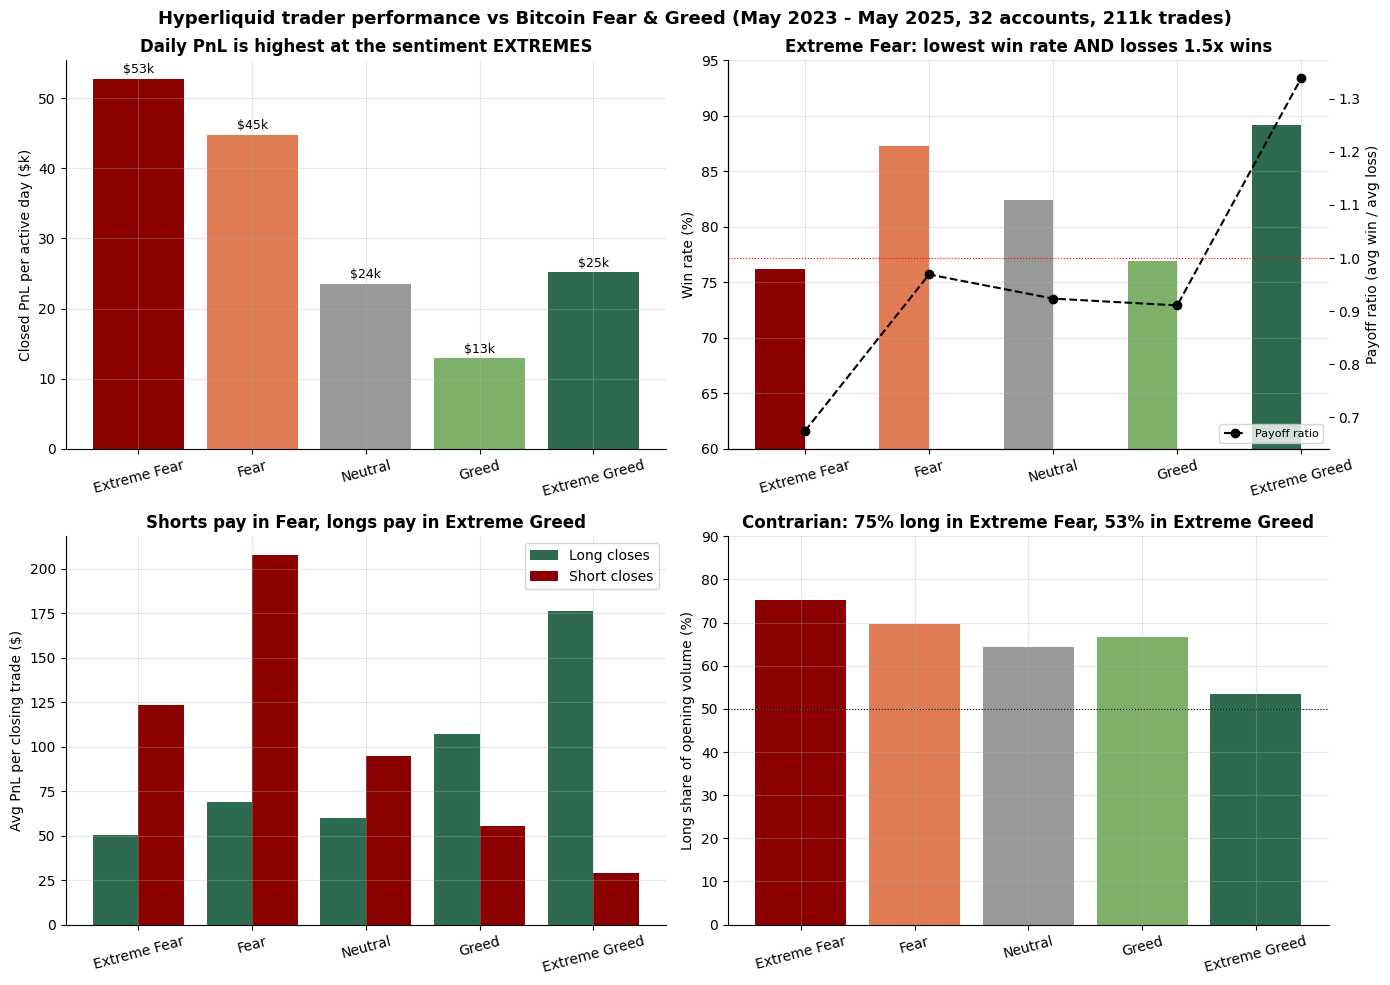

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
clist = [COLORS[s] for s in ORDER]
x = np.arange(5)

# 1. PnL per active day
perday = (perf["total_pnl"] / perf["active_days"]).reindex(ORDER)
axes[0, 0].bar(x, perday.values / 1000, color=clist)
axes[0, 0].set_xticks(x, ORDER, rotation=15)
axes[0, 0].set_ylabel("Closed PnL per active day ($k)")
axes[0, 0].set_title("Daily PnL is highest at the sentiment EXTREMES", fontweight="bold")
for i, v in enumerate(perday.values / 1000):
    axes[0, 0].text(i, v + 0.8, f"${v:,.0f}k", ha="center", fontsize=9)

# 2. Win rate + payoff ratio
ax = axes[0, 1]
ax.bar(x - 0.2, perf["win_rate"].reindex(ORDER).values * 100, width=0.4, color=clist)
ax2 = ax.twinx()
ax2.plot(x, perf["payoff_ratio"].reindex(ORDER).values, "ko--", label="Payoff ratio")
ax2.axhline(1, color="red", lw=0.8, ls=":")
ax2.set_ylabel("Payoff ratio (avg win / avg loss)")
ax2.grid(False)
ax.set_xticks(x, ORDER, rotation=15)
ax.set_ylabel("Win rate (%)")
ax.set_ylim(60, 95)
ax.set_title("Extreme Fear: lowest win rate AND losses 1.5x wins", fontweight="bold")
ax2.legend(loc="lower right", fontsize=8)

# 3. Long vs short avg PnL
lsm = ls.pivot_table(index="sentiment", columns="close_side", values="Closed PnL",
                     aggfunc="mean", observed=True).reindex(ORDER)
axes[1, 0].bar(x - 0.2, lsm["Long"], width=0.4, color="#2d6a4f", label="Long closes")
axes[1, 0].bar(x + 0.2, lsm["Short"], width=0.4, color="#8b0000", label="Short closes")
axes[1, 0].set_xticks(x, ORDER, rotation=15)
axes[1, 0].set_ylabel("Avg PnL per closing trade ($)")
axes[1, 0].set_title("Shorts pay in Fear, longs pay in Extreme Greed", fontweight="bold")
axes[1, 0].legend()

# 4. Contrarian positioning
share = pos["long_share_of_open_volume"].reindex(ORDER)
axes[1, 1].bar(x, share.values * 100, color=clist)
axes[1, 1].axhline(50, color="black", lw=0.8, ls=":")
axes[1, 1].set_xticks(x, ORDER, rotation=15)
axes[1, 1].set_ylabel("Long share of opening volume (%)")
axes[1, 1].set_title("Contrarian: 75% long in Extreme Fear, 53% in Extreme Greed", fontweight="bold")
axes[1, 1].set_ylim(0, 90)

fig.suptitle("Hyperliquid trader performance vs Bitcoin Fear & Greed (May 2023 - May 2025, 32 accounts, 211k trades)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("outputs/dashboard.png", dpi=130, bbox_inches="tight")
plt.show()

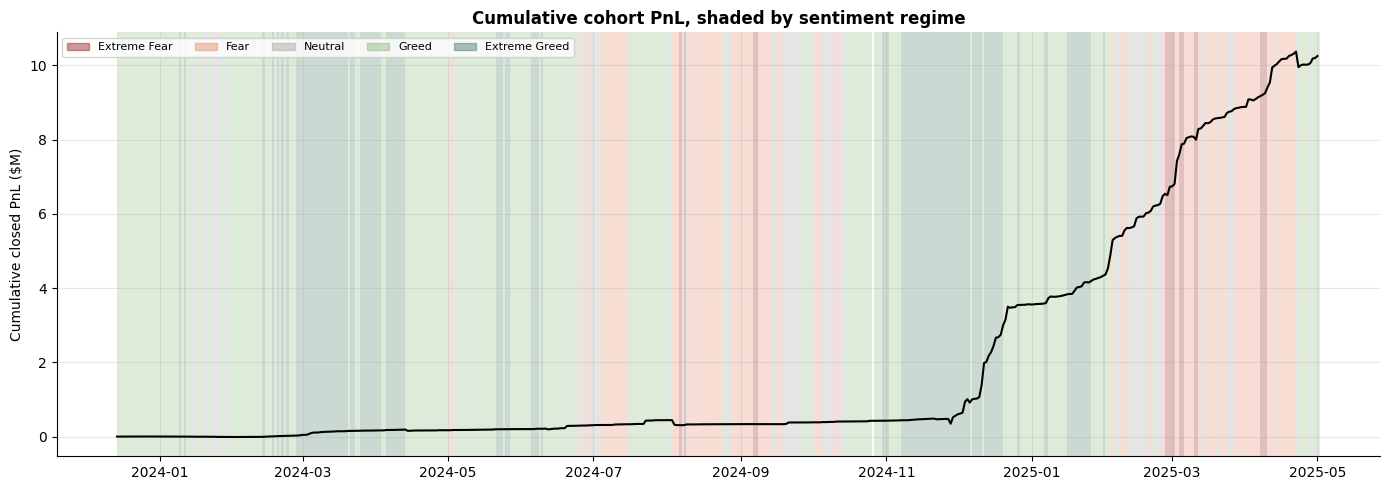

saved outputs/dashboard.png, outputs/timeline.png and aggregated CSVs


In [14]:
# Cumulative PnL timeline shaded by daily sentiment regime
dd = closed.groupby("date")["Closed PnL"].sum().reindex(
    pd.date_range(closed["date"].min(), closed["date"].max()), fill_value=0)
cum = dd.cumsum()
fsub = fg[fg["date"].between(dd.index.min(), dd.index.max())]
fig2, ax = plt.subplots(figsize=(14, 5))
for _, row in fsub.iterrows():
    ax.axvspan(row["date"], row["date"] + pd.Timedelta(days=1),
               color=COLORS[row["sentiment"]], alpha=0.25, lw=0)
ax.plot(cum.index, cum.values / 1e6, color="black", lw=1.5)
ax.set_ylabel("Cumulative closed PnL ($M)")
ax.set_title("Cumulative cohort PnL, shaded by sentiment regime", fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[s], alpha=0.4) for s in ORDER]
ax.legend(handles, ORDER, loc="upper left", fontsize=8, ncol=5)
fig2.tight_layout()
fig2.savefig("outputs/timeline.png", dpi=130, bbox_inches="tight")
plt.show()

# Save aggregated outputs
perf.to_csv("outputs/perf_by_sentiment.csv")
daily.to_csv("outputs/daily_pnl_sentiment.csv")
print("saved outputs/dashboard.png, outputs/timeline.png and aggregated CSVs")

The timeline makes the behavioral story visible: the cohort was roughly **flat through the Greed-heavy 2024**, then earned almost the entire \$10.3M during the **Fear / Extreme Fear-heavy December 2024 – May 2025** stretch — consistent with their contrarian buy-the-fear positioning.

## 9. Conclusions & strategy implications

1. **Trade the extremes, fade the middle.** Both sentiment extremes outperform; plain Greed days are the worst regime by every metric. Reduce activity (or expectations) on ordinary Greed days and concentrate on Extreme Fear, Fear, and Extreme Greed days.
2. **Match direction to regime.** Short into Fear (\$208/trade, 86% win); ride longs in Extreme Greed (\$176/trade, 91% win); never short an Extreme Greed melt-up, and avoid fading plain Greed early.
3. **Risk-manage Extreme Fear specifically.** It is the only regime where average losses exceed average wins (payoff 0.67) and the left tail is ~5x fatter. Smaller size / tighter stops there would convert the highest-$ regime into a sustainable one.
4. **Buy fear, trim into euphoria.** The cohort's monotonic contrarian positioning (75% → 53% long share) coincided with essentially all of its \$10.3M PnL.
5. **Watch regime flips.** Sentiment classification changes — especially *into* Fear — marked the most profitable days (~2–3x stable days).

**Limitations:** 32 accounts with 45.7% of PnL in the top 3 (pattern survives their exclusion); coin mix is confounded with regime/time; sentiment is BTC-based but applied to all coins; Closed PnL excludes fees (~3% of PnL in most regimes, 1% in Extreme Greed); no leverage column in this export, so leverage effects could not be isolated.